In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import igraph as ig

In [ ]:
import cvxpy as cp

In [ ]:
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('font', family='serif',size=10)
plt.rc('text', usetex=True)

In [5]:
def add_odd_col(graph, N):
    size = graph.vcount()
    graph.add_vertices(N+1)
    edges = [(size-N, size)]

    for i in range(1, N):
        edges.append((size - N + i - 1, size + i))
        edges.append((size - N + i, size + i))
    
    edges.append((size - 1, size + N))

    graph.add_edges(edges)

def add_even_col(graph, N):
    size = graph.vcount()
    graph.add_vertices(N)
    edges = []

    for i in range(N):
        edges.append((size - N + i - 1, size + i))
        edges.append((size - N + i, size + i))
    
    graph.add_edges(edges)


def create_diamond_lattice(N):
    graph = ig.Graph(directed=True)
    
    graph.add_vertices(N)

    for i in range(1, 2*N + 1):
        if (i % 2 == 1):
            add_odd_col(graph, N)
        else:
            add_even_col(graph, N)

    return graph

In [6]:
def bound_condition(graph):
    num_edges = graph.ecount()
    ineq_matrix = np.zeros([2*num_edges, num_edges], dtype=np.int64)
    ineq_vector = np.ones(2*num_edges, dtype=np.int64)
    ineq_vector[::2] = 0

    for i in range(num_edges):
        ineq_matrix[2*i][i] = -1
        ineq_matrix[2*i + 1][i] = 1

    return ineq_matrix, ineq_vector

# assume start_nodes have zero in-degree, stop_nodes have zero out-degree
def kirchoff_law_condition(graph, start_nodes, stop_nodes):
    size = graph.vcount()
    num_edges = graph.ecount()
    num_conditions = size - len(start_nodes) - len(stop_nodes) + 2
    eq_matrix = np.zeros([num_conditions, num_edges], dtype=np.int64)
    eq_vector = np.zeros(num_conditions, dtype=np.int64)

    condition = np.zeros(num_edges, dtype=np.int64)
    for i in start_nodes:
        start_edges = graph.incident(i, mode='out')
        for edge in start_edges:
            condition[edge] = 1

    eq_matrix[0] = condition
    eq_vector[0] = 1

    all_nodes = [i for i in range(size)]
    regular_nodes = np.array([i for i in all_nodes if ((i not in start_nodes) and (i not in stop_nodes))])
    count = 1

    for i in regular_nodes:
        in_edges = graph.incident(i, mode='in')
        out_edges = graph.incident(i, mode='out')

        condition = np.zeros(num_edges, dtype=np.int64)
        for in_edge in in_edges:
            condition[in_edge] = -1
        for out_edge in out_edges:
            condition[out_edge] = 1
        
        eq_matrix[count] = condition
        eq_vector[count] = 0
        count += 1

    condition = np.zeros(num_edges, dtype=np.int64)
    for i in stop_nodes:
        stop_edges = graph.incident(i, mode='in')
        for edge in stop_edges:
            condition[edge] = 1

    eq_matrix[-1] = condition
    eq_vector[-1] = 1

    return eq_matrix, eq_vector

def quad_coeff(road_types):
    quad_matrix = np.zeros([len(road_types), len(road_types)], dtype=np.int64)
    
    for k in range(len(road_types)):
        quad_matrix[k][k] = road_types[k]

    return quad_matrix

def linear_coeff(road_types):
    linear_vector = np.zeros(len(road_types), dtype=np.int64)

    for k in range(len(road_types)):
        linear_vector[k] = (road_types[k] + 1) % 2

    return linear_vector

def assign_road_type(graph, p):
    num_edges = graph.ecount()
    
    road_types = np.zeros(num_edges, dtype=np.int64)
    for i in range(num_edges):
        if (random.random() < p):
            road_types[i] = 1

    return road_types

def commute_time(roads, road_types):
    commute = 0
    for k in range(len(roads)):
        if(road_types[k] == 0):
            commute += roads[k]
        else:
            commute += roads[k]**2
    
    return commute


In [33]:
p_vals = np.arange(0, 1, 0.05)
N = 10
diamond_lattice = create_diamond_lattice(N)
eq_matrix, eq_vector = kirchoff_law_condition(diamond_lattice, [i for i in range(N)], [diamond_lattice.vcount() - N + i for i in range(N)])
ineq_matrix, ineq_vector = bound_condition(diamond_lattice)
eq_commute_times = np.zeros_like(p_vals)
op_commute_times = np.zeros_like(p_vals)

In [36]:
total_op_commute = np.zeros_like(p_vals)
total_eq_commute = np.zeros_like(p_vals)

for i in range(100):    
    for m in range(len(p_vals)):
        road_types = assign_road_type(diamond_lattice, p_vals[m])
        quadratic_coefficients = quad_coeff(road_types)
        linear_coefficients = linear_coeff(road_types)

        x = cp.Variable(4*N*N)

        P = quadratic_coefficients
        q = linear_coefficients
        G = ineq_matrix
        h = ineq_vector
        A = eq_matrix
        b = eq_vector

        eq_prob = cp.Problem(cp.Minimize((1/2)*cp.quad_form(x, P) + q.T @ x),
                        [G @ x <= h,
                        A @ x == b])
        eq_prob.solve()

        sol = np.array(x.value)
        rounded_sol = np.abs(np.round(sol, decimals=5))

        eq_commute = commute_time(rounded_sol, road_types)

        y = cp.Variable(4*N*N)
        P = 2*P
        op_prob = cp.Problem(cp.Minimize((1/2)*cp.quad_form(y, P) + q.T @ y),
                        [G @ y <= h,
                        A @ y == b])
        op_prob.solve()

        sol = np.array(y.value)
        rounded_sol = np.abs(np.round(sol, decimals=5))

        op_commute = commute_time(rounded_sol, road_types)

        eq_commute_times[m] = eq_commute
        op_commute_times[m] = op_commute

        total_eq_commute += eq_commute_times
        total_op_commute += op_commute_times

avg_eq_commute = total_eq_commute / 100
avg_op_commute = total_op_commute / 100


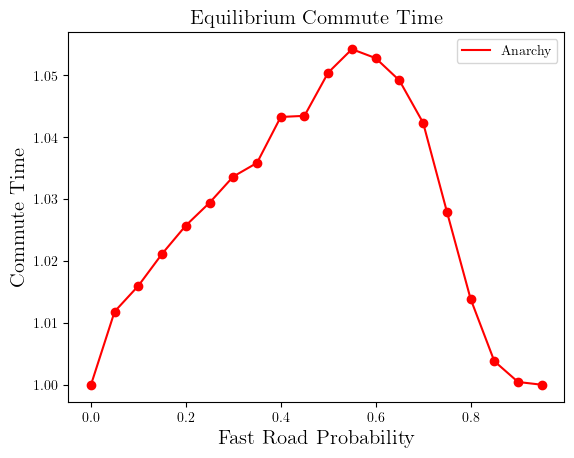

In [39]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

# ax.plot(p_vals, eq_commute_times, color='black', label='Equilibrium')
# ax.scatter(p_vals, eq_commute_times, color='black')
#ax.set_yscale('log')

# ax.plot(p_vals, op_commute_times, color='red', label='Optimum')
# ax.scatter(p_vals, op_commute_times, color='red')

ax.plot(p_vals, avg_eq_commute / avg_op_commute, color='red', label='Anarchy')
ax.scatter(p_vals, avg_eq_commute / avg_op_commute, color='red')

ax.set_ylabel("Commute Time", fontsize=15)
ax.set_xlabel("Fast Road Probability", fontsize=15)
ax.set_title("Equilibrium Commute Time", fontsize=15)


ax.legend()